  PROJET PROB & STAT — VERSION 2 (3 paramétrages / figure)


══ PARTIE 1 — CONTRÔLE QUALITÉ ══

───────────────────────────────────────────────────────
  Original  — n=50, p=5%
───────────────────────────────────────────────────────
  E[X] théorique = 2.5000   |  simulé = 2.4660
  σ(X) théorique = 1.5411   |  simulé = 1.5244
  P(X=0)         = 7.69%
  P(X>5)         = 3.78%
  Seuil 95%      = 5 défauts

───────────────────────────────────────────────────────
  Variante A — n=100, p=10%
───────────────────────────────────────────────────────
  E[X] théorique = 10.0000   |  simulé = 10.0022
  σ(X) théorique = 3.0000   |  simulé = 2.9957
  P(X=0)         = 0.00%
  P(X>5)         = 94.24%
  Seuil 95%      = 15 défauts

───────────────────────────────────────────────────────
  Variante B — n=30, p=2%
───────────────────────────────────────────────────────
  E[X] théorique = 0.6000   |  simulé = 0.5957
  σ(X) théorique = 0.7668   |  simulé = 0.7640
  P(X=0)         = 54.55%
  P(X>5)         

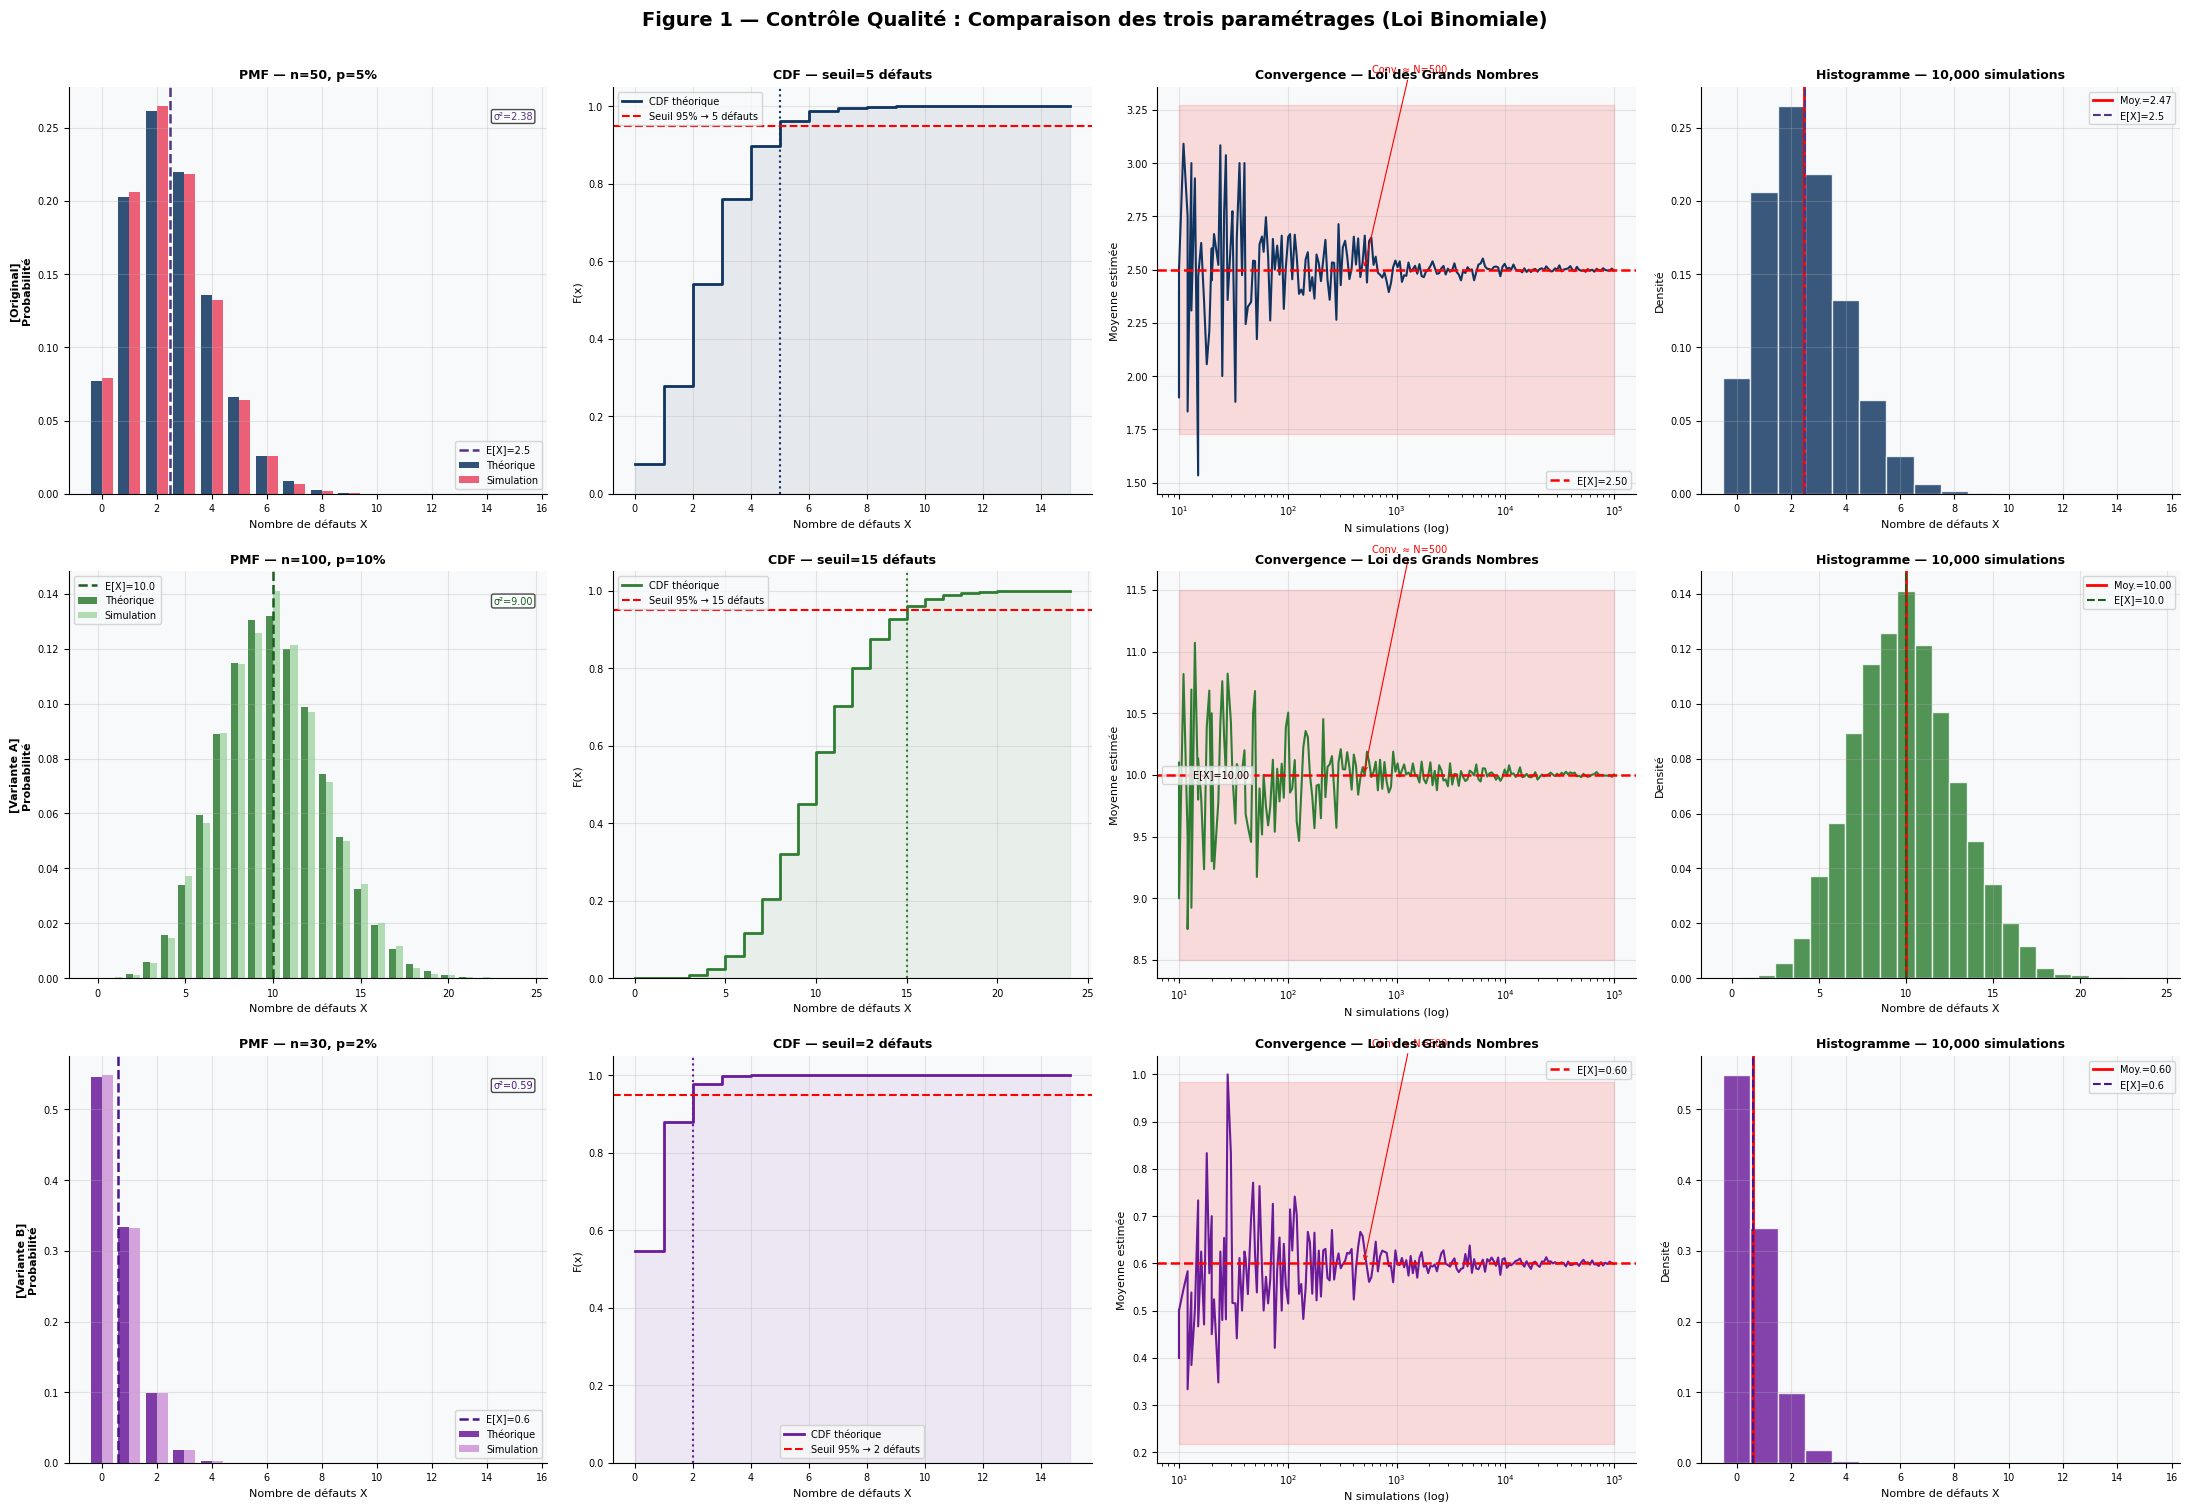



══ PARTIE 2 — DURÉE DE VIE ══

───────────────────────────────────────────────────────
  Original  — λ=0.01 | β=2, η=100
───────────────────────────────────────────────────────
  MTTF Exp  : théo=100.0h
  MTTF Wei  : théo=88.6h  |  simulé=88.7h
  R(100h)   : Exp=0.3679  Wei=0.3679
  Test KS   : stat=0.0194, p-val=0.8396  ✅

───────────────────────────────────────────────────────
  Variante A — λ=0.005 | β=0.7, η=200  [Mortalité infantile]
───────────────────────────────────────────────────────
  MTTF Exp  : théo=200.0h
  MTTF Wei  : théo=253.2h  |  simulé=234.8h
  R(100h)   : Exp=0.6065  Wei=0.5403
  Test KS   : stat=0.0265, p-val=0.4779  ✅

───────────────────────────────────────────────────────
  Variante B — λ=0.02  | β=3.5, η=60   [Usure accélérée]
───────────────────────────────────────────────────────
  MTTF Exp  : théo=50.0h
  MTTF Wei  : théo=54.0h  |  simulé=53.3h
  R(100h)   : Exp=0.1353  Wei=0.0025
  Test KS   : stat=0.0248, p-val=0.5603  ✅

✅ Figure 2 sauvegardée → graphi

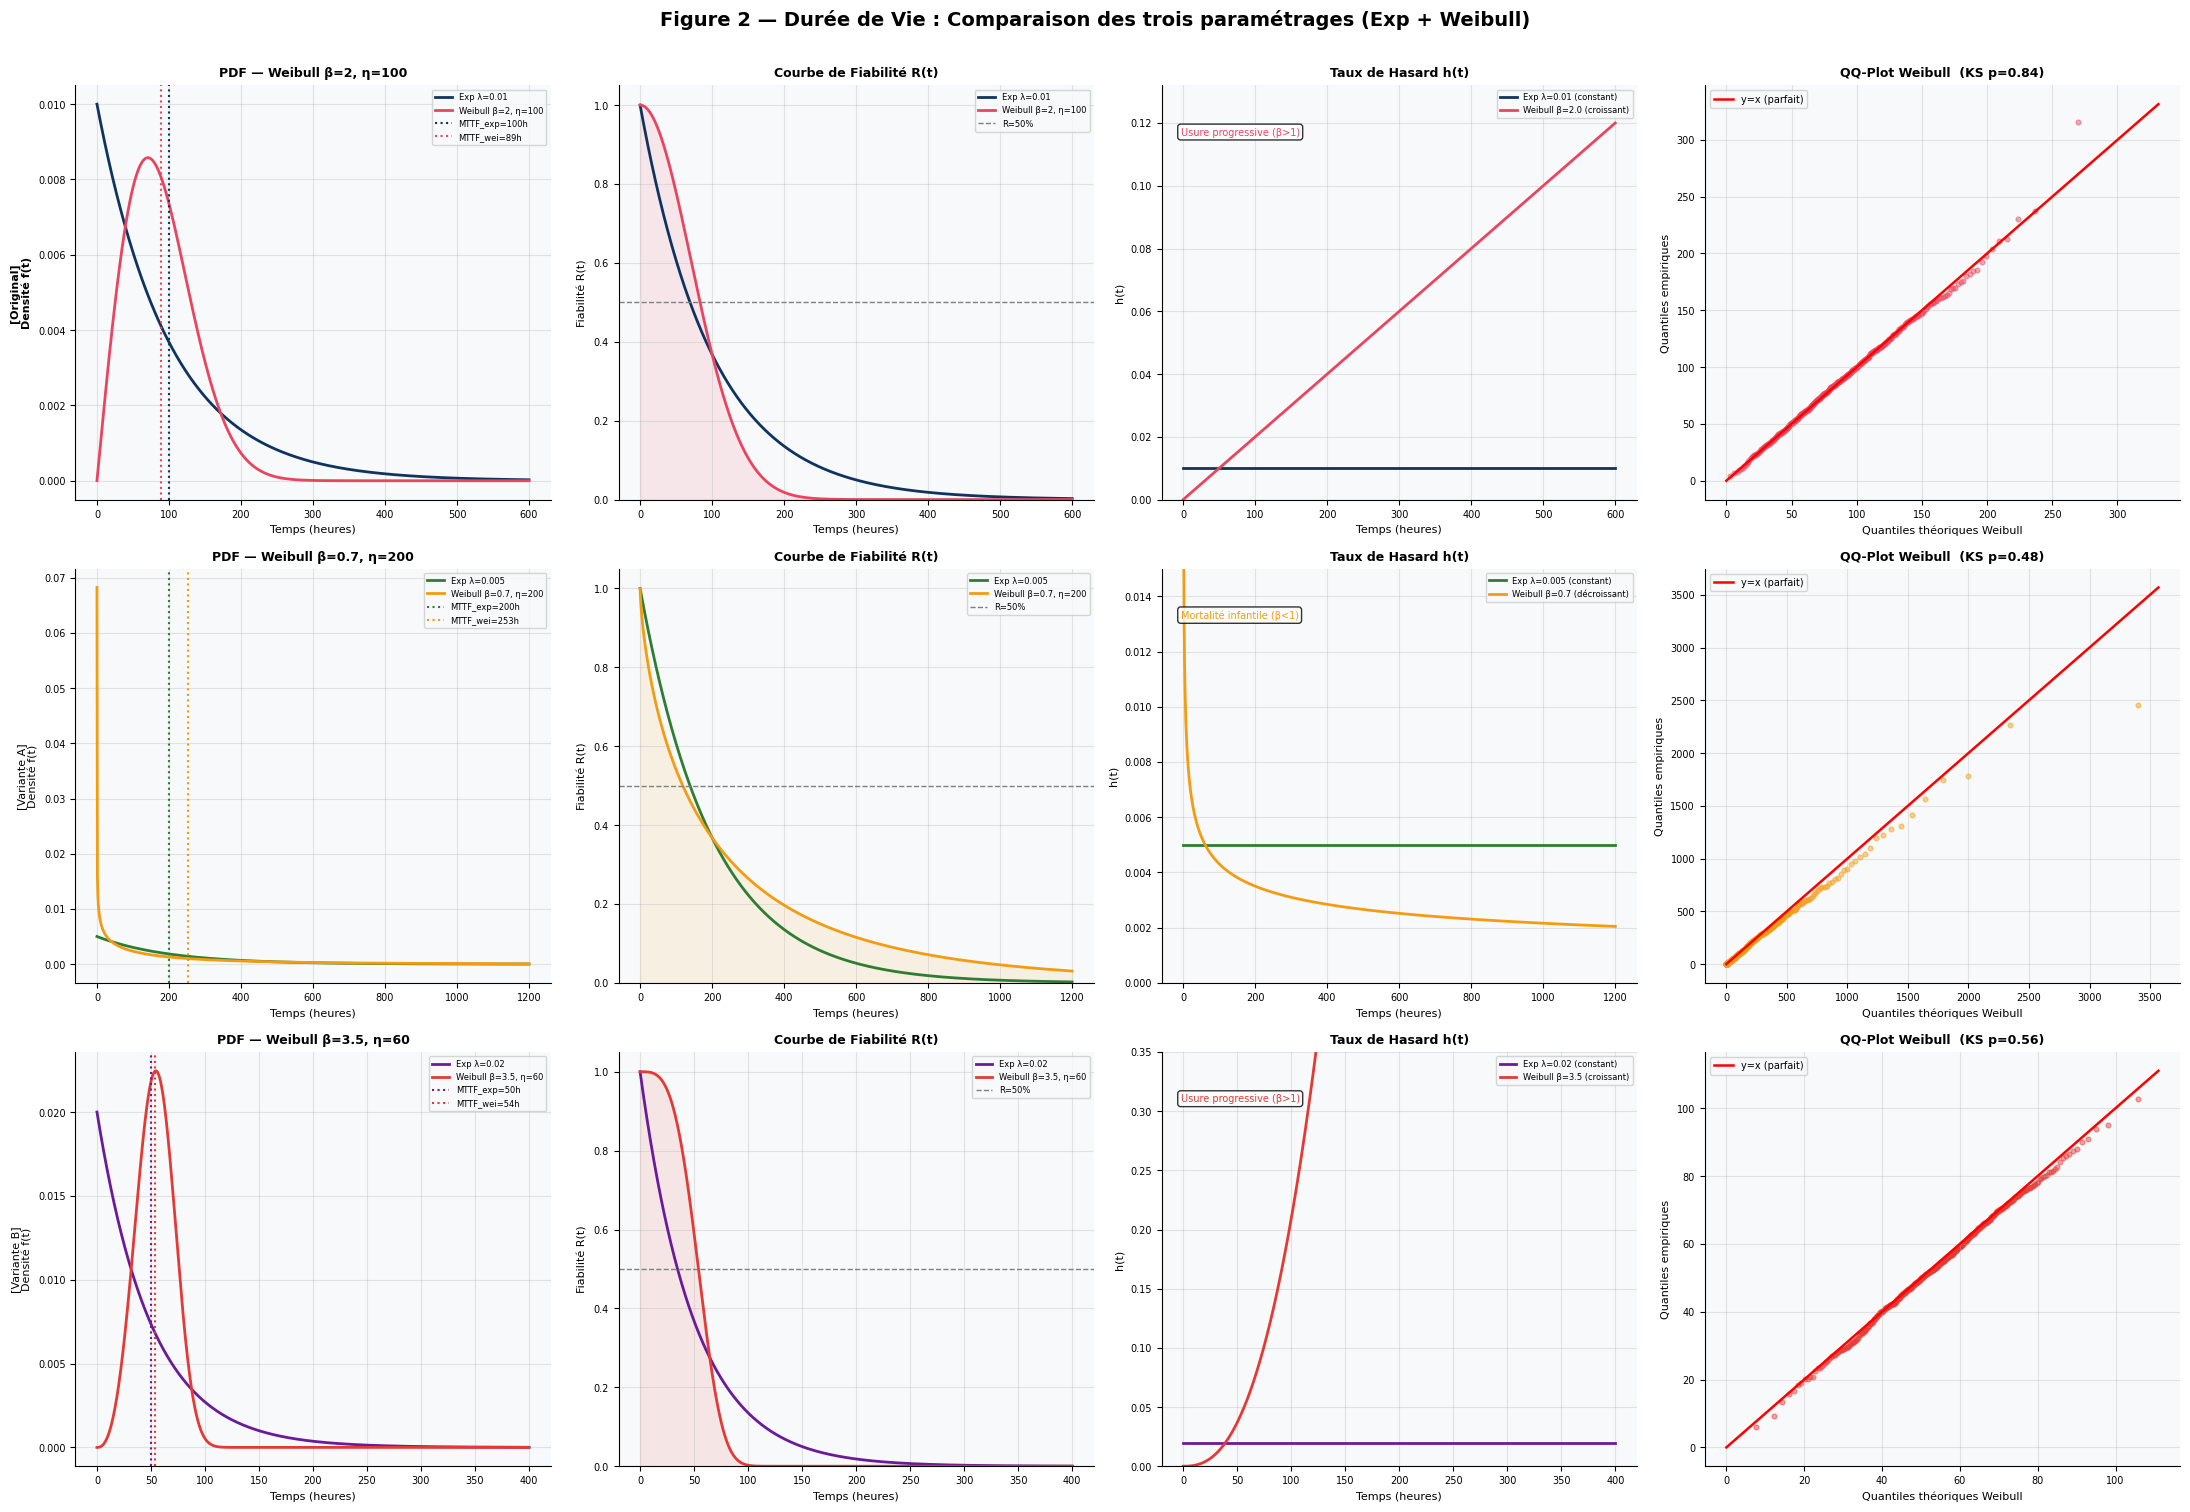



══ PARTIE 3 — ANALYSE COMBINÉE ══

───────────────────────────────────────────────────────
  Original  — β=2, η=100
───────────────────────────────────────────────────────
  R_Weibull(100h) = 0.3679
  p=1% → R_sys = 0.3350
  p=5% → R_sys = 0.1028
  p=10% → R_sys = 0.0124
  p=15% → R_sys = 0.0011
  p=20% → R_sys = 0.0001

───────────────────────────────────────────────────────
  Variante A — β=0.7, η=200  [Composants robustes]
───────────────────────────────────────────────────────
  R_Weibull(100h) = 0.5403
  p=1% → R_sys = 0.4920
  p=5% → R_sys = 0.1510
  p=10% → R_sys = 0.0183
  p=15% → R_sys = 0.0016
  p=20% → R_sys = 0.0001

───────────────────────────────────────────────────────
  Variante B — β=3.5, η=60   [Composants fragiles]
───────────────────────────────────────────────────────
  R_Weibull(100h) = 0.0025
  p=1% → R_sys = 0.0023
  p=5% → R_sys = 0.0007
  p=10% → R_sys = 0.0001
  p=15% → R_sys = 0.0000
  p=20% → R_sys = 0.0000

✅ Figure 3 sauvegardée → graphique3_combinee_v2

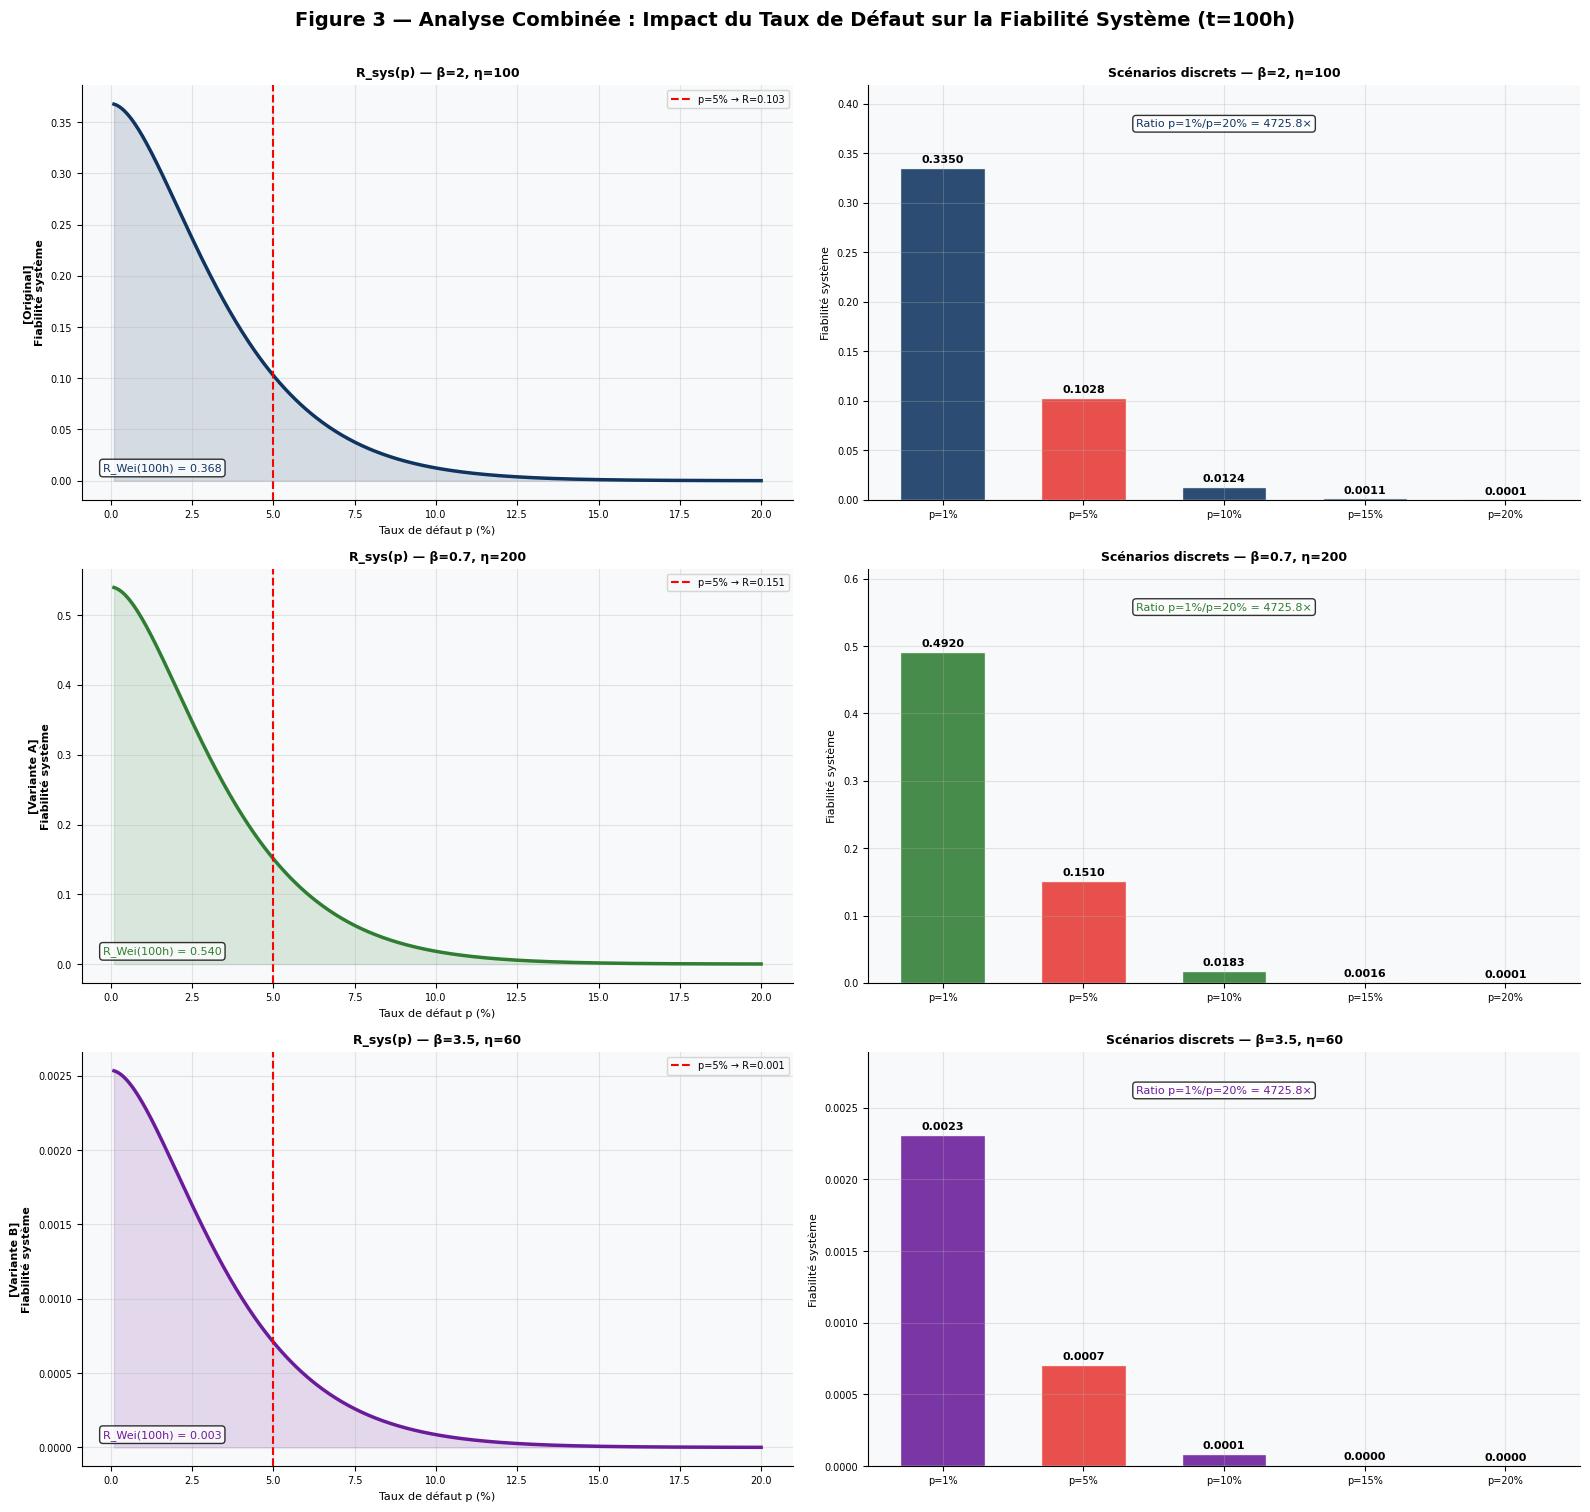


  ✅ SIMULATION TERMINÉE — 3 figures générées et affichées.
  📁 Fichiers : graphique1_..._v2.png  graphique2_..._v2.png  graphique3_..._v2.png


In [9]:
"""
Projet Probabilités & Statistiques
Sujet : Contrôle Qualité en Usine + Durée de Vie de Composants Électriques
Groupe de 3+ | Python | 1ère Année Cycle Ingénieur (IGIT 1)

VERSION 2 — Comparaison de 3 paramétrages par figure
"""

# ─── Installation ─────────────────────────────────────────────────────────────
# !pip install scipy numpy matplotlib seaborn   # décommenter si nécessaire

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from scipy.special import gamma as gamma_func
import math
import warnings
warnings.filterwarnings('ignore')

# ─── Paramètres globaux ───────────────────────────────────────────────────────
np.random.seed(42)

plt.rcParams.update({
    'font.family'        : 'DejaVu Sans',
    'axes.facecolor'     : '#f8f9fa',
    'figure.facecolor'   : 'white',
    'axes.spines.top'    : False,
    'axes.spines.right'  : False,
    'axes.grid'          : True,
    'grid.alpha'         : 0.3,
    'axes.titlesize'     : 9,
    'axes.labelsize'     : 8,
    'xtick.labelsize'    : 7,
    'ytick.labelsize'    : 7,
    'legend.fontsize'    : 7,
})

N_SIMULATIONS = 10_000   # Monte-Carlo commun à toutes les parties


# ══════════════════════════════════════════════════════════════════════════════
# PARTIE 1 — CONTRÔLE QUALITÉ (Loi Binomiale) — 3 paramétrages
# ══════════════════════════════════════════════════════════════════════════════

# ─── Définition des 3 jeux de paramètres ─────────────────────────────────────
CONFIGS_BINOM = [
    dict(
        n=50, p=0.05,
        label="Original  — n=50, p=5%",
        short="n=50, p=5%",
        color_th ="#0f3460",
        color_sim="#e94560",
        color_acc="#533483",
    ),
    dict(
        n=100, p=0.10,
        label="Variante A — n=100, p=10%",
        short="n=100, p=10%",
        color_th ="#2E7D32",
        color_sim="#A5D6A7",
        color_acc="#1B5E20",
    ),
    dict(
        n=30, p=0.02,
        label="Variante B — n=30, p=2%",
        short="n=30, p=2%",
        color_th ="#6A1B9A",
        color_sim="#CE93D8",
        color_acc="#4A148C",
    ),
]


def simuler_binomiale(cfg, n_sim=N_SIMULATIONS):
    """Calcule tous les résultats théoriques + simulés pour une config binomiale."""
    n, p = cfg['n'], cfg['p']
    sim   = np.random.binomial(n, p, n_sim)
    x_max = max(int(stats.binom.ppf(0.9995, n, p)) + 3, 15)
    x     = np.arange(0, x_max + 1)
    pmf   = stats.binom.pmf(x, n, p)
    cdf   = stats.binom.cdf(x, n, p)
    seuil = int(stats.binom.ppf(0.95, n, p))

    # Convergence LGN
    sizes = np.logspace(1, 5, 200).astype(int)
    moyennes = [np.mean(np.random.binomial(n, p, s)) for s in sizes]

    print(f"\n{'─'*55}")
    print(f"  {cfg['label']}")
    print(f"{'─'*55}")
    print(f"  E[X] théorique = {n*p:.4f}   |  simulé = {np.mean(sim):.4f}")
    print(f"  σ(X) théorique = {np.sqrt(n*p*(1-p)):.4f}   |  simulé = {np.std(sim):.4f}")
    print(f"  P(X=0)         = {stats.binom.pmf(0, n, p)*100:.2f}%")
    print(f"  P(X>5)         = {(1-stats.binom.cdf(5, n, p))*100:.2f}%")
    print(f"  Seuil 95%      = {seuil} défauts")

    return dict(x=x, pmf=pmf, cdf=cdf, seuil=seuil, sim=sim,
                sizes=sizes, moyennes=moyennes, n_sim=n_sim, **cfg)


def tracer_figure1(results):
    """
    Figure 1 : 3 lignes × 4 colonnes
      col 0 = PMF théo vs sim
      col 1 = CDF + seuil critique
      col 2 = convergence LGN
      col 3 = histogramme Monte-Carlo
    """
    fig, axes = plt.subplots(3, 4, figsize=(22, 15))
    fig.suptitle(
        "Figure 1 — Contrôle Qualité : Comparaison des trois paramétrages (Loi Binomiale)",
        fontsize=14, fontweight='bold', y=1.005
    )

    for row, r in enumerate(results):
        n, p = r['n'], r['p']
        c_th, c_sim, c_acc = r['color_th'], r['color_sim'], r['color_acc']
        mu = n * p

        # ── (a) PMF ──────────────────────────────────────────────────────────
        ax = axes[row, 0]
        w = 0.4
        freq_sim = np.array([np.mean(r['sim'] == k) for k in r['x']])
        ax.bar(r['x'] - w/2, r['pmf'],    w, color=c_th,  alpha=0.85, label='Théorique')
        ax.bar(r['x'] + w/2, freq_sim, w, color=c_sim, alpha=0.85, label='Simulation')
        ax.axvline(mu, color=c_acc, ls='--', lw=1.8, label=f'E[X]={mu:.1f}')
        ax.set_title(f"PMF — {r['short']}", fontweight='bold')
        ax.set_xlabel("Nombre de défauts X")
        ax.set_ylabel("Probabilité")
        ax.legend()
        # Annotation espérance + variance
        ax.annotate(
            f"σ²={n*p*(1-p):.2f}",
            xy=(0.97, 0.92), xycoords='axes fraction',
            ha='right', fontsize=7, color=c_acc,
            bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7)
        )

        # ── (b) CDF ──────────────────────────────────────────────────────────
        ax = axes[row, 1]
        ax.step(r['x'], r['cdf'], color=c_th, lw=2, where='post', label='CDF théorique')
        ax.axhline(0.95, color='red', ls='--', lw=1.5,
                   label=f"Seuil 95% → {r['seuil']} défauts")
        ax.axvline(r['seuil'], color=c_th, ls=':', lw=1.5)
        ax.fill_between(r['x'], r['cdf'], step='post', alpha=0.08, color=c_th)
        ax.set_ylim(0, 1.05)
        ax.set_title(f"CDF — seuil={r['seuil']} défauts", fontweight='bold')
        ax.set_xlabel("Nombre de défauts X")
        ax.set_ylabel("F(x)")
        ax.legend()

        # ── (c) Convergence LGN ───────────────────────────────────────────────
        ax = axes[row, 2]
        ax.plot(r['sizes'], r['moyennes'], color=c_th, lw=1.5)
        ax.axhline(mu, color='red', ls='--', lw=1.8, label=f'E[X]={mu:.2f}')
        sigma = np.sqrt(n * p * (1 - p))
        ax.fill_between(r['sizes'], mu - sigma/2, mu + sigma/2,
                        alpha=0.12, color='red')
        ax.set_xscale('log')
        ax.set_title("Convergence — Loi des Grands Nombres", fontweight='bold')
        ax.set_xlabel("N simulations (log)")
        ax.set_ylabel("Moyenne estimée")
        ax.legend()
        ax.annotate("Conv. ≈ N=500",
                    xy=(500, mu), xytext=(600, mu + sigma * 0.6),
                    fontsize=7, color='red',
                    arrowprops=dict(arrowstyle='->', color='red', lw=0.8))

        # ── (d) Histogramme ───────────────────────────────────────────────────
        ax = axes[row, 3]
        bins = np.arange(-0.5, max(r['x']) + 1.5, 1)
        ax.hist(r['sim'], bins=bins, density=True,
                color=c_th, alpha=0.82, edgecolor='white')
        moy_sim = np.mean(r['sim'])
        ax.axvline(moy_sim, color='red', lw=2, label=f'Moy.={moy_sim:.2f}')
        ax.axvline(mu,     color=c_acc, lw=1.5, ls='--', label=f'E[X]={mu:.1f}')
        ax.set_title(f"Histogramme — {r['n_sim']:,} simulations", fontweight='bold')
        ax.set_xlabel("Nombre de défauts X")
        ax.set_ylabel("Densité")
        ax.legend()

    # Étiquettes de ligne (Original / Variante A / Variante B)
    labels_rows = ["Original", "Variante A", "Variante B"]
    for row, lbl in enumerate(labels_rows):
        axes[row, 0].set_ylabel(f"[{lbl}]\nProbabilité", fontsize=8, fontweight='bold')

    plt.tight_layout()
    plt.savefig("graphique1_controle_qualite_v2.png", dpi=150, bbox_inches='tight')
    print("\n✅ Figure 1 sauvegardée → graphique1_controle_qualite_v2.png")
    plt.show()
    plt.close()


# ══════════════════════════════════════════════════════════════════════════════
# PARTIE 2 — DURÉE DE VIE (Exponentielle + Weibull) — 3 paramétrages
# ══════════════════════════════════════════════════════════════════════════════

CONFIGS_WEIB = [
    dict(
        lam=0.01,  beta=2.0, eta=100,
        label="Original  — λ=0.01 | β=2, η=100",
        short_exp="Exp λ=0.01", short_wei="Weibull β=2, η=100",
        c_exp="#0f3460", c_wei="#e94560",
    ),
    dict(
        lam=0.005, beta=0.7, eta=200,
        label="Variante A — λ=0.005 | β=0.7, η=200  [Mortalité infantile]",
        short_exp="Exp λ=0.005", short_wei="Weibull β=0.7, η=200",
        c_exp="#2E7D32", c_wei="#F39C12",
    ),
    dict(
        lam=0.02,  beta=3.5, eta=60,
        label="Variante B — λ=0.02  | β=3.5, η=60   [Usure accélérée]",
        short_exp="Exp λ=0.02",  short_wei="Weibull β=3.5, η=60",
        c_exp="#6A1B9A", c_wei="#E53935",
    ),
]


def simuler_weibull(cfg, n_comp=1000):
    """Calcule tous les résultats théoriques + simulés pour une config durée de vie."""
    lam, beta, eta = cfg['lam'], cfg['beta'], cfg['eta']
    t_max = max(400, int(6 / lam))
    t     = np.linspace(0.01, t_max, 1000)

    mttf_exp = 1 / lam
    mttf_wei = eta * math.gamma(1 + 1 / beta)

    pdf_exp = lam * np.exp(-lam * t)
    R_exp   = np.exp(-lam * t)
    h_exp   = np.full_like(t, lam)

    pdf_wei = (beta / eta) * (t / eta)**(beta - 1) * np.exp(-(t / eta)**beta)
    R_wei   = np.exp(-(t / eta)**beta)
    h_wei   = (beta / eta) * (t / eta)**(beta - 1)

    sim_wei = eta * np.random.weibull(beta, n_comp)
    ks_stat, ks_pval = stats.kstest(
        sim_wei / eta, 'weibull_min', args=(beta,)
    )

    print(f"\n{'─'*55}")
    print(f"  {cfg['label']}")
    print(f"{'─'*55}")
    print(f"  MTTF Exp  : théo={mttf_exp:.1f}h")
    print(f"  MTTF Wei  : théo={mttf_wei:.1f}h  |  simulé={np.mean(sim_wei):.1f}h")
    print(f"  R(100h)   : Exp={np.exp(-lam*100):.4f}  Wei={np.exp(-(100/eta)**beta):.4f}")
    print(f"  Test KS   : stat={ks_stat:.4f}, p-val={ks_pval:.4f}  "
          f"{'✅' if ks_pval>0.05 else '⚠️ '}")

    return dict(
        t=t, t_max=t_max,
        pdf_exp=pdf_exp, R_exp=R_exp, h_exp=h_exp, mttf_exp=mttf_exp,
        pdf_wei=pdf_wei, R_wei=R_wei, h_wei=h_wei, mttf_wei=mttf_wei,
        sim_wei=sim_wei, ks_pval=ks_pval,
        **cfg
    )


def tracer_figure2(results):
    """
    Figure 2 : 3 lignes × 4 colonnes
      col 0 = PDF  col 1 = R(t)  col 2 = h(t)  col 3 = QQ-plot Weibull
    """
    fig, axes = plt.subplots(3, 4, figsize=(22, 15))
    fig.suptitle(
        "Figure 2 — Durée de Vie : Comparaison des trois paramétrages (Exp + Weibull)",
        fontsize=14, fontweight='bold', y=1.005
    )

    labels_rows = ["Original", "Variante A\n(Mortalité infantile)", "Variante B\n(Usure rapide)"]

    for row, r in enumerate(results):
        t     = r['t']
        c_exp = r['c_exp']
        c_wei = r['c_wei']

        # ── (a) PDF ──────────────────────────────────────────────────────────
        ax = axes[row, 0]
        ax.plot(t, r['pdf_exp'], color=c_exp, lw=2, label=r['short_exp'])
        ax.plot(t, r['pdf_wei'], color=c_wei, lw=2, label=r['short_wei'])
        ax.axvline(r['mttf_exp'], color=c_exp, ls=':', lw=1.5,
                   label=f"MTTF_exp={r['mttf_exp']:.0f}h")
        ax.axvline(r['mttf_wei'], color=c_wei, ls=':', lw=1.5,
                   label=f"MTTF_wei={r['mttf_wei']:.0f}h")
        ax.set_title(f"PDF — {r['short_wei']}", fontweight='bold')
        ax.set_xlabel("Temps (heures)")
        ax.set_ylabel(f"[{labels_rows[row].splitlines()[0]}]\nDensité f(t)",
                      fontweight='bold' if row == 0 else 'normal')
        ax.legend(fontsize=6)

        # ── (b) Fiabilité R(t) ────────────────────────────────────────────────
        ax = axes[row, 1]
        ax.plot(t, r['R_exp'], color=c_exp, lw=2, label=r['short_exp'])
        ax.plot(t, r['R_wei'], color=c_wei, lw=2, label=r['short_wei'])
        ax.fill_between(t, r['R_wei'], alpha=0.10, color=c_wei)
        ax.axhline(0.5, color='gray', ls='--', lw=1, label='R=50%')
        ax.set_ylim(0, 1.05)
        ax.set_title("Courbe de Fiabilité R(t)", fontweight='bold')
        ax.set_xlabel("Temps (heures)")
        ax.set_ylabel("Fiabilité R(t)")
        ax.legend(fontsize=6)

        # ── (c) Taux de hasard h(t) ───────────────────────────────────────────
        ax = axes[row, 2]
        ax.plot(t, r['h_exp'], color=c_exp, lw=2, label=f'{r["short_exp"]} (constant)')
        ax.plot(t, r['h_wei'], color=c_wei, lw=2,
                label=f'Weibull β={r["beta"]} ({"décroissant" if r["beta"]<1 else "croissant"})')
        h_max_display = min(r['h_wei'][-1] * 1.1, 0.35)
        ax.set_ylim(0, max(h_max_display, r['lam'] * 3))
        ax.set_title("Taux de Hasard h(t)", fontweight='bold')
        ax.set_xlabel("Temps (heures)")
        ax.set_ylabel("h(t)")
        ax.legend(fontsize=6)
        # Annotation du régime Weibull
        regime = ("Mortalité infantile (β<1)" if r['beta'] < 1
                  else "Usure progressive (β>1)" if r['beta'] > 1
                  else "Taux constant (β=1)")
        ax.annotate(regime, xy=(0.04, 0.88), xycoords='axes fraction',
                    fontsize=7, color=c_wei,
                    bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8))

        # ── (d) QQ-plot ───────────────────────────────────────────────────────
        ax = axes[row, 3]
        n_comp = len(r['sim_wei'])
        p_grid = (np.arange(1, n_comp + 1) - 0.3) / (n_comp + 0.4)
        q_emp  = np.sort(r['sim_wei'])
        q_th   = r['eta'] * (-np.log(1 - p_grid))**(1 / r['beta'])
        step   = max(1, n_comp // 300)
        ax.scatter(q_th[::step], q_emp[::step],
                   color=c_wei, alpha=0.45, s=12)
        lim = max(q_th[-1], q_emp[-1]) * 1.05
        ax.plot([0, lim], [0, lim], color='red', lw=1.8, label='y=x (parfait)')
        ax.set_title(f"QQ-Plot Weibull  (KS p={r['ks_pval']:.2f})", fontweight='bold')
        ax.set_xlabel("Quantiles théoriques Weibull")
        ax.set_ylabel("Quantiles empiriques")
        ax.legend(fontsize=7)

    plt.tight_layout()
    plt.savefig("graphique2_duree_vie_v2.png", dpi=150, bbox_inches='tight')
    print("\n✅ Figure 2 sauvegardée → graphique2_duree_vie_v2.png")
    plt.show()
    plt.close()


# ══════════════════════════════════════════════════════════════════════════════
# PARTIE 3 — ANALYSE COMBINÉE — 3 paramétrages Weibull
# ══════════════════════════════════════════════════════════════════════════════

CONFIGS_SYS = [
    dict(beta=2.0, eta=100, taille_lot=50,
         label="Original  — β=2, η=100",
         short="β=2, η=100",  color="#0f3460"),
    dict(beta=0.7, eta=200, taille_lot=50,
         label="Variante A — β=0.7, η=200  [Composants robustes]",
         short="β=0.7, η=200", color="#2E7D32"),
    dict(beta=3.5, eta=60,  taille_lot=50,
         label="Variante B — β=3.5, η=60   [Composants fragiles]",
         short="β=3.5, η=60",  color="#6A1B9A"),
]

SCENARIOS_P = [0.01, 0.05, 0.10, 0.15, 0.20]
T_EVAL      = 100   # horizon d'évaluation (heures)


def calculer_fiabilite_sys(cfg):
    """Fiabilité système = P(lot ok) × R_Weibull(T_EVAL)."""
    beta, eta, n_lot = cfg['beta'], cfg['eta'], cfg['taille_lot']
    R_wei_t = np.exp(-(T_EVAL / eta)**beta)

    p_range = np.linspace(0.001, 0.20, 500)
    # P(lot ok) = P(X ≤ 1) avec X~Binom(n_lot, p)  (0 ou 1 défaut toléré)
    R_sys   = np.array([stats.binom.cdf(1, n_lot, p) * R_wei_t for p in p_range])
    vals_sc = np.array([stats.binom.cdf(1, n_lot, p) * R_wei_t for p in SCENARIOS_P])

    print(f"\n{'─'*55}")
    print(f"  {cfg['label']}")
    print(f"{'─'*55}")
    print(f"  R_Weibull({T_EVAL}h) = {R_wei_t:.4f}")
    for p_t, v in zip(SCENARIOS_P, vals_sc):
        print(f"  p={p_t:.0%} → R_sys = {v:.4f}")

    return dict(p_range=p_range, R_sys=R_sys, R_wei_t=R_wei_t,
                vals_sc=vals_sc, **cfg)


def tracer_figure3(results):
    """
    Figure 3 : 3 lignes × 2 colonnes
      col 0 = courbe R_sys(p) continue
      col 1 = histogramme par scénario discret
    """
    fig, axes = plt.subplots(3, 2, figsize=(16, 15))
    fig.suptitle(
        f"Figure 3 — Analyse Combinée : Impact du Taux de Défaut "
        f"sur la Fiabilité Système (t={T_EVAL}h)",
        fontsize=14, fontweight='bold', y=1.005
    )

    bar_colors_base = ["#0f3460", "#e94560", "#533483", "#16213e", "#f5a623"]

    for row, r in enumerate(results):
        color = r['color']

        # ── (a) Courbe continue R_sys(p) ──────────────────────────────────────
        ax = axes[row, 0]
        ax.plot(r['p_range'] * 100, r['R_sys'], color=color, lw=2.5)
        ax.fill_between(r['p_range'] * 100, r['R_sys'], alpha=0.15, color=color)
        ax.axvline(5, color='red', ls='--', lw=1.5,
                   label=f"p=5% → R={r['vals_sc'][1]:.3f}")
        ax.set_title(f"R_sys(p) — {r['short']}", fontweight='bold')
        ax.set_xlabel("Taux de défaut p (%)")
        ax.set_ylabel("Fiabilité système")
        ax.legend()
        # Annotations clés
        ax.annotate(
            f"R_Wei({T_EVAL}h) = {r['R_wei_t']:.3f}",
            xy=(0.03, 0.07), xycoords='axes fraction',
            fontsize=8, color=color,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8)
        )

        # ── (b) Histogramme scénarios discrets ────────────────────────────────
        ax = axes[row, 1]
        bar_cols = [color if p != 0.05 else '#E53935' for p in SCENARIOS_P]
        bars = ax.bar(
            [f"p={int(p*100)}%" for p in SCENARIOS_P],
            r['vals_sc'],
            color=bar_cols, alpha=0.88, edgecolor='white', width=0.6
        )
        for bar, val in zip(bars, r['vals_sc']):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(r['vals_sc']) * 0.01,
                f'{val:.4f}', ha='center', va='bottom',
                fontsize=8, fontweight='bold'
            )
        ax.set_title(f"Scénarios discrets — {r['short']}", fontweight='bold')
        ax.set_ylabel("Fiabilité système")
        ax.set_ylim(0, max(r['vals_sc']) * 1.25)
        ax.grid(axis='y', alpha=0.3)

        # Ratio p=1% / p=20%
        ratio = r['vals_sc'][0] / max(r['vals_sc'][-1], 1e-9)
        ax.annotate(
            f"Ratio p=1%/p=20% = {ratio:.1f}×",
            xy=(0.5, 0.90), xycoords='axes fraction', ha='center',
            fontsize=8, color=color,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8)
        )

    # Étiquettes de ligne
    labels_rows = ["Original", "Variante A\n(Robustes)", "Variante B\n(Fragiles)"]
    for row, lbl in enumerate(labels_rows):
        axes[row, 0].set_ylabel(
            f"[{lbl.splitlines()[0]}]\nFiabilité système",
            fontsize=8, fontweight='bold'
        )

    plt.tight_layout()
    plt.savefig("graphique3_combinee_v2.png", dpi=150, bbox_inches='tight')
    print("\n✅ Figure 3 sauvegardée → graphique3_combinee_v2.png")
    plt.show()
    plt.close()


# ══════════════════════════════════════════════════════════════════════════════
# SCRIPT PRINCIPAL
# ══════════════════════════════════════════════════════════════════════════════

if __name__ == "__main__":
    print("=" * 60)
    print("  PROJET PROB & STAT — VERSION 2 (3 paramétrages / figure)")
    print("=" * 60)

    # ── PARTIE 1 — Binomiale ──────────────────────────────────────────────────
    print("\n\n══ PARTIE 1 — CONTRÔLE QUALITÉ ══")
    res_binom = [simuler_binomiale(cfg) for cfg in CONFIGS_BINOM]
    tracer_figure1(res_binom)

    # ── PARTIE 2 — Durée de vie ───────────────────────────────────────────────
    print("\n\n══ PARTIE 2 — DURÉE DE VIE ══")
    res_weib = [simuler_weibull(cfg) for cfg in CONFIGS_WEIB]
    tracer_figure2(res_weib)

    # ── PARTIE 3 — Analyse combinée ───────────────────────────────────────────
    print("\n\n══ PARTIE 3 — ANALYSE COMBINÉE ══")
    res_sys = [calculer_fiabilite_sys(cfg) for cfg in CONFIGS_SYS]
    tracer_figure3(res_sys)

    print("\n" + "=" * 60)
    print("  ✅ SIMULATION TERMINÉE — 3 figures générées et affichées.")
    print("  📁 Fichiers : graphique1_..._v2.png  graphique2_..._v2.png  graphique3_..._v2.png")
    print("=" * 60)